In [4]:
# Requiero Mesa >= 3.5
# Importamos las clases que se requieren para manejar los agentes (Agent) y su entorno (Model).
# Cada modelo puede contener múltiples agentes.
from mesa import Agent, Model

# Debido a que necesitamos que existe un solo agente por celda, elegimos ''SingleGrid''.
from mesa.space import SingleGrid

# Haremos uso de ''DataCollector'' para obtener información de cada paso de la simulación.
from mesa.datacollection import DataCollector

# Haremos uso de ''batch_run'' para ejecutar varias simulaciones
from mesa.batchrunner import batch_run

# matplotlib lo usaremos crear una animación de cada uno de los pasos del modelo.
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Importamos los siguientes paquetes para el mejor manejo de valores numéricos.
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

# Importamos esta librería para generar numeros aleatorios más adelante
import sys
import random
from matplotlib.colors import ListedColormap

import heapq


In [ ]:
#POIs
ROWS_POIS = 6
COLS_POIS = 8

POIS_INICIALES = [(2, 4), (5, 1), (5, 8)]

# Bolsa 10 Victimas + 5 Falsas Alarmas activas en toda la partida
bolsa_pois = {"victima": 10, "falsa_alarma": 5}

def sacar_poi_de_bolsa(bolsa_pois):
    tipos_disponibles = (["victima"] * bolsa_pois["victima"]) + (["falsa_alarma"] * bolsa_pois["falsa_alarma"])
    if not tipos_disponibles:
        return None  # bolsa agotada
    tipo = random.choice(tipos_disponibles)
    bolsa_pois[tipo] -= 1
    return 2 if tipo == "victima" else 1

#0 = vacio, 1 = falsa alarma, 2 = victima
matrixPois = np.zeros((ROWS_POIS, COLS_POIS), dtype=int)
matrixPoisRevelado = np.zeros((ROWS_POIS, COLS_POIS), dtype=bool)

for (fila, columna) in POIS_INICIALES:
    r, c = fila - 1, columna - 1
    matrixPois[r, c] = sacar_poi_de_bolsa(bolsa_pois)
    # matrixPoisRevelado queda en False: se colocan boca abajo

Victimas perdidas al final de la simulacion: 2 (limite de derrota: 4)


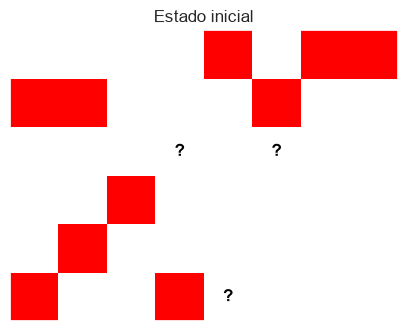

In [ ]:
# Fuego

ROWS_FUEGO = 6
COLS_FUEGO = 8

FUEGO_INICIAL = [
    (1, 7), (4, 3), (5, 2), (1, 5), (2, 2),
    (2, 6), (6, 1), (1, 8), (2, 1), (6, 4),
]

# 0 = vacio, 1 = humo, 2 = fuego
matrixFuego = np.zeros((ROWS_FUEGO, COLS_FUEGO), dtype=int)


for fila, columna in FUEGO_INICIAL:
    matrixFuego[fila - 1, columna - 1] = 2

def revelar_y_perder_poi(r, c, matrixPois, matrixPoisRevelado):
    if matrixPois[r, c] == 0:
        return None
    tipo = "victima_perdida" if matrixPois[r, c] == 2 else "falsa_alarma_quemada"
    matrixPoisRevelado[r, c] = True  # el fuego revela el POI justo antes de destruirlo
    matrixPois[r, c] = 0
    return (tipo, r, c)

# Falta poner el daño a las paredes
# Falta hacer debilitamiento si cae un fuego en un bombero
# Falta: revelar un POI (matrixPoisRevelado[r, c] = True) cuando un bombero entra a esa celda,

def explosion(r, c, matrix, matrixPois, matrixPoisRevelado):

    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # arriba, abajo, izquierda, derecha
    eventos_pois = []
    for dr, dc in direcciones:
        nr, nc = r + dr, c + dc
        while 0 <= nr < ROWS_FUEGO and 0 <= nc < COLS_FUEGO and matrix[nr, nc] == 2:
            nr += dr
            nc += dc
        if 0 <= nr < ROWS_FUEGO and 0 <= nc < COLS_FUEGO:
            matrix[nr, nc] = 2  # vacio o humo -> fuego
            evento = revelar_y_perder_poi(nr, nc, matrixPois, matrixPoisRevelado)
            if evento is not None:
                eventos_pois.append(evento)
    return eventos_pois

def flashover(matrix, matrixPois, matrixPoisRevelado):

    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    eventos_pois = []
    cambio = True
    while cambio:
        cambio = False
        for i in range(ROWS_FUEGO):
            for j in range(COLS_FUEGO):
                if matrix[i, j] != 1:
                    continue
                for dr, dc in direcciones:
                    ni, nj = i + dr, j + dc
                    if 0 <= ni < ROWS_FUEGO and 0 <= nj < COLS_FUEGO and matrix[ni, nj] == 2:
                        matrix[i, j] = 2
                        cambio = True
                        evento = revelar_y_perder_poi(i, j, matrixPois, matrixPoisRevelado)
                        if evento is not None:
                            eventos_pois.append(evento)
                        break
    return eventos_pois

def advance_fire(matrix, matrixPois, matrixPoisRevelado):

    fila = random.randint(1, ROWS_FUEGO)
    columna = random.randint(1, COLS_FUEGO)
    r, c = fila - 1, columna - 1
    eventos_pois = []

    # Cae humo (no afecta POIs)
    if matrix[r, c] == 0:
        matrix[r, c] = 1

    # Se convierte en fuego
    elif matrix[r, c] == 1:
        matrix[r, c] = 2
        evento = revelar_y_perder_poi(r, c, matrixPois, matrixPoisRevelado)
        if evento is not None:
            eventos_pois.append(evento)

    # Explosion
    elif matrix[r, c] == 2:
        eventos_pois.extend(explosion(r, c, matrix, matrixPois, matrixPoisRevelado))

    return fila, columna, eventos_pois

N_POIS_OBJETIVO = 3


def replenish_poi(matrixFuego, matrixPois, matrixPoisRevelado, bolsa_pois):
    eventos = []
    while np.count_nonzero(matrixPois) < N_POIS_OBJETIVO:        
        r = random.randint(0, ROWS_FUEGO - 1)
        c = random.randint(0, COLS_FUEGO - 1)
        if matrixPois[r, c] != 0:
            continue  # ya hay un POI ahi: reroll
        tipo_valor = sacar_poi_de_bolsa(bolsa_pois)
        if tipo_valor is None:
            return eventos  # bolsa agotada, no se puede reponer mas
        matrixFuego[r, c] = 0  # limpiar fuego/humo antes de colocar el POI
        matrixPois[r, c] = tipo_valor
        matrixPoisRevelado[r, c] = False
        eventos.append(("poi_repuesto", r, c))
    return eventos

N_TURNOS_FUEGO = 20
LIMITE_VICTIMAS_PERDIDAS = 4  # derrota con 4+ victimas perdidas

historyFuego = [matrixFuego.copy()]
historyPois = [matrixPois.copy()]
historyPoisRevelado = [matrixPoisRevelado.copy()]
historyTargetFuego = [None]
historyEventoFuego = [None]
historyEventosPois = [[]]

victimas_perdidas = 0
derrota = False

for turno in range(N_TURNOS_FUEGO):
    antes = matrixFuego.copy()
    fila, columna, eventos_ignicion = advance_fire(matrixFuego, matrixPois, matrixPoisRevelado)
    evento = "explosion" if antes[fila - 1, columna - 1] == 2 else None
    eventos_flashover = flashover(matrixFuego, matrixPois, matrixPoisRevelado)
    eventos_replenish = replenish_poi(matrixFuego, matrixPois, matrixPoisRevelado, bolsa_pois)

    eventos_turno = eventos_ignicion + eventos_flashover + eventos_replenish
    victimas_perdidas += sum(1 for (tipo, *_r) in eventos_turno if tipo == "victima_perdida")

    historyFuego.append(matrixFuego.copy())
    historyPois.append(matrixPois.copy())
    historyPoisRevelado.append(matrixPoisRevelado.copy())
    historyTargetFuego.append((fila, columna))
    historyEventoFuego.append(evento)
    historyEventosPois.append(eventos_turno)

    if victimas_perdidas >= LIMITE_VICTIMAS_PERDIDAS:
        derrota = True
        print(f"DERROTA: se perdieron {victimas_perdidas} victimas en el turno {turno + 1}.")
        break

if not derrota:
    print(f"Victimas perdidas al final de la simulacion: {victimas_perdidas} (limite de derrota: {LIMITE_VICTIMAS_PERDIDAS})")

fuego_cmap = ListedColormap(["white", "gray", "red"])
fig_fuego, ax_fuego = plt.subplots(figsize=(5, 4))
ax_fuego.set_xticks([])
ax_fuego.set_yticks([])
patch_fuego = ax_fuego.imshow(historyFuego[0], cmap=fuego_cmap, vmin=0, vmax=2)
title_fuego = ax_fuego.set_title("Estado inicial")

def dibujar_pois(frame_idx):
    for txt in list(ax_fuego.texts):
        txt.remove()
    matriz_pois = historyPois[frame_idx]
    matriz_revelado = historyPoisRevelado[frame_idx]
    for i in range(ROWS_POIS):
        for j in range(COLS_POIS):
            if matriz_pois[i, j] == 0:
                continue
            if not matriz_revelado[i, j]:
                ax_fuego.text(j, i, "?", ha="center", va="center", color="black", fontweight="bold")
            elif matriz_pois[i, j] == 2:
                ax_fuego.text(j, i, "V", ha="center", va="center", color="blue", fontweight="bold")
            else:
                ax_fuego.text(j, i, "F", ha="center", va="center", color="green", fontweight="bold")

def animate_fuego(i):
    patch_fuego.set_data(historyFuego[i])
    dibujar_pois(i)
    target = historyTargetFuego[i]
    if target is None:
        title_fuego.set_text("Estado inicial")
    else:
        evento = historyEventoFuego[i]
        extra = " - EXPLOSION" if evento == "explosion" else ""
        eventos_turno = historyEventosPois[i]
        if eventos_turno:
            extra += " | " + ", ".join(f"{tipo} en ({r+1},{c+1})" for tipo, r, c in eventos_turno)
        title_fuego.set_text(f"Turno {i} - cae en (fila {target[0]}, columna {target[1]}){extra}")
    return patch_fuego, title_fuego

anim_fuego = animation.FuncAnimation(
    fig_fuego, animate_fuego, frames=len(historyFuego), interval=600
)
anim_fuego